# Manipulação Básica de Imagens

Neste caderno, abordaremos como realizar transformações de imagens, incluindo:

* Acesso e manipulação de pixels em imagens
* Redimensionamento de imagens
* Recorte
* Inversão

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image 
from IPython.display import Image
%matplotlib inline

### <font style="color:rgb(8,133,37)">Imagem original do tabuleiro de xadrez</font>

### O "Problema" do Matplotlib

Quando você usa o comando cb_img = cv2.imread("checkerboard_18x18.png", 0), o OpenCV lê a imagem estritamente como uma matriz de duas dimensões, onde cada pixel é apenas um número de 0 a 255 (0 é totalmente preto, 255 é totalmente branco). Se você der o print(cb_img), verá exatamente essa matriz de números.

Porém, a biblioteca matplotlib.pyplot (plt) foi projetada originalmente para visualização de dados matemáticos e gráficos estatísticos, não especificamente para fotografia.

Se você apenas rodar plt.imshow(cb_img) sem o cmap='gray', o Matplotlib olhará para aqueles números de 0 a 255 e pensará: "Isso é um mapa de calor matemático!". Por padrão, ele aplicará um mapa de cores chamado Viridis, renderizando sua imagem em tons de roxo, azul e amarelo, em vez de preto e branco.

### O papel do cmap='gray' (Color Map)
O argumento cmap significa Colormap (Mapa de Cores). Quando você define cmap='gray', você está dando uma ordem explícita para o Matplotlib:

"Não tente inventar cores. Pegue o valor mais baixo da matriz (0) e pinte de preto, pegue o valor mais alto (255) e pinte de branco, e distribua os valores intermediários em tons de cinza."

[[  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [255 255 255 255 255 255   0   0   0   0   0   0 255 255 255 255 255 255]
 [255 255 255 255 255 255   0   0   0   0   0   0 255 255 255 255 255 255]
 [255 255 255 255 255 255   0   0   0   0   0   0 255 255 255 255 255 255]
 [255 255 255 255 255 255   0   0   0   0   0   0 255 255 255 255 255 255]
 [255 255 255 255 255 255   0   0   0   0   0   0 255 255 255 255 255 255]
 [255 255 255 255 255 255   0   0   0   0   0   0 255 255 255 255 255 255]
 [  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [  0   0   0   0   0   0

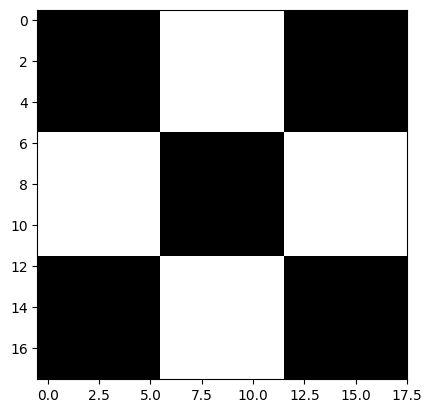

In [3]:
# Ler imagem em escala de cinza.
cb_img = cv2.imread("checkerboard_18x18.png",0)

# Defina o mapa de cores para escala de cinza para uma renderização adequada.
plt.imshow(cb_img, cmap='gray')
print(cb_img)

## Acessando Pixels Individuais
Vamos ver como acessar um pixel na imagem.

Para acessar qualquer pixel em uma matriz NumPy, você precisa usar a notação matricial, como `matrix[r,c]`, onde `r` é o número da linha e `c` é o número da coluna. Observe também que a matriz é indexada a partir de 0.

Por exemplo, se você quiser acessar o primeiro pixel, precisa especificar `matrix[0,0]`. Vejamos alguns exemplos. Vamos imprimir um pixel preto do canto superior esquerdo e um pixel branco do centro superior.

In [4]:
# print the first pixel of the first black box
print(cb_img[0,0])
# print the first white pixel to the right of the first black box
print(cb_img[0,6])

0
255


## <font style="color:white">Modificando Pixels da Imagem</font>
Podemos modificar os valores de intensidade dos pixels da mesma maneira descrita acima.

[[  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [  0   0 200 200   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [  0   0 200 200   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [255 255 255 255 255 255   0   0   0   0   0   0 255 255 255 255 255 255]
 [255 255 255 255 255 255   0   0   0   0   0   0 255 255 255 255 255 255]
 [255 255 255 255 255 255   0   0   0   0   0   0 255 255 255 255 255 255]
 [255 255 255 255 255 255   0   0   0   0   0   0 255 255 255 255 255 255]
 [255 255 255 255 255 255   0   0   0   0   0   0 255 255 255 255 255 255]
 [255 255 255 255 255 255   0   0   0   0   0   0 255 255 255 255 255 255]
 [  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [  0   0   0   0   0   0

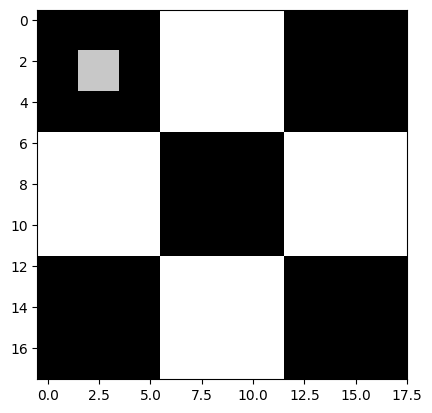

In [5]:
cb_img_copy = cb_img.copy()
cb_img_copy[2,2] = 200
cb_img_copy[2,3] = 200
cb_img_copy[3,2] = 200
cb_img_copy[3,3] = 200

# Same as above
# cb_img_copy[2:3,2:3] = 200

plt.imshow(cb_img_copy, cmap='gray')
print(cb_img_copy)

# Recorte de Imagens

Recortar uma imagem é feito simplesmente selecionando uma região específica (em pixels) da imagem.

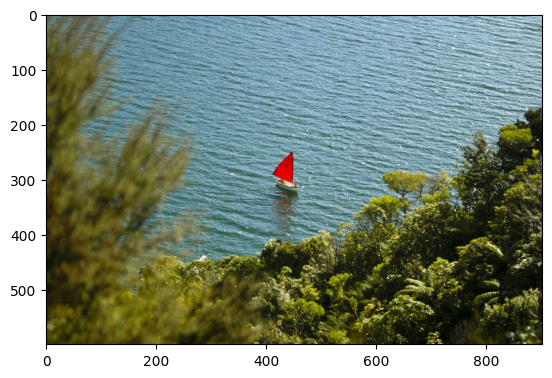

In [6]:
img_NZ_bgr = cv2.imread("New_Zealand_Boat.jpg",cv2.IMREAD_COLOR)
img_NZ_rgb = img_NZ_bgr[:,:,::-1] 

plt.imshow(img_NZ_rgb)

### <font color="green">Recortar a região central da imagem</font>

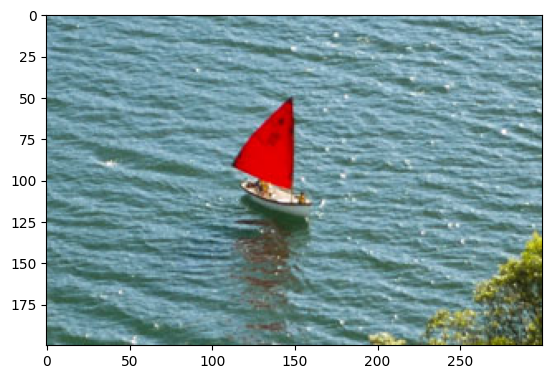

In [7]:
cropped_region = img_NZ_rgb[200:400, 300:600]
plt.imshow(cropped_region)

# Redimensionando Imagens

A função **`resize`** redimensiona a imagem `src` para cima ou para baixo até o tamanho especificado. O tamanho e o tipo são derivados de `src`, `dsize`, `fx` e `fy`.

### <font style="color:rgb(8,133,37)">Sintaxe da Função</font>
``` python
dst = resize( src, dsize[, dst[, fx[, fy[, interpolation]]]] )
```

`dst`: imagem de saída; tem o tamanho dsize (quando diferente de zero) ou o tamanho calculado a partir de src.size(), fx e fy; o tipo de dst é o mesmo de src.

A função possui **2 argumentos obrigatórios**:

1. `src`: imagem de entrada
2. `dsize`: tamanho da imagem de saída

Argumentos opcionais frequentemente utilizados incluem:

1. `fx`: Fator de escala no eixo horizontal; quando igual a 0, é calculado como (dsize)dsize.width/src.cs
2. `fy`: Fator de escala no eixo vertical; Quando é igual a 0, é calculado como (𝚍𝚘𝚞𝚋𝚕𝚎)𝚍𝚜𝚒𝚣𝚎.𝚑𝚎𝚒𝚐𝚑𝚝/𝚜𝚛𝚌.𝚛𝚘𝚠𝚜

A imagem de saída tem o tamanho `dsize` (quando diferente de zero) ou o tamanho calculado a partir de `src.size()`, `fx` e `fy`; o tipo de `dst` é o mesmo de `src`.

### <font style="color:rgb(8,133,37)">Documentação do OpenCV</font>

**`resize():`** https://docs.opencv.org/4.5.0/da/d54/group__imgproc__transform.html#ga47a974309e9102f5f08231edc7e7529d

### <font color="green">Método 1: Especificando o fator de escala usando fx e fy

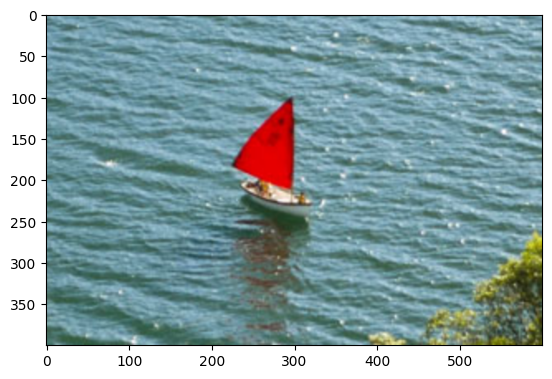

In [8]:
resized_cropped_region_2x = cv2.resize(cropped_region,None,fx=2, fy=2)
plt.imshow(resized_cropped_region_2x)

### <font color="green">Método 2: Especificando o tamanho exato da imagem de saída</font>

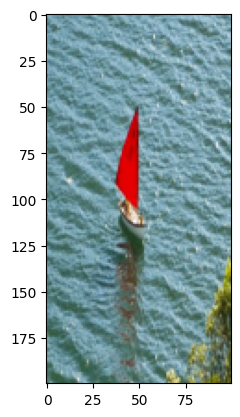

In [9]:
desired_width = 100
desired_height = 200
dim = (desired_width, desired_height)

# Resize background image to sae size as logo image
resized_cropped_region = cv2.resize(cropped_region, dsize=dim, interpolation=cv2.INTER_AREA)
plt.imshow(resized_cropped_region)

### <font color="green">Redimensionar mantendo a proporção</font>

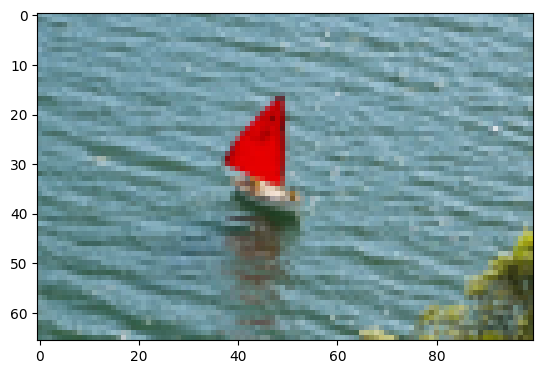

In [10]:
# Method 2: Using 'dsize'
desired_width = 100
aspect_ratio = desired_width / cropped_region.shape[1]
desired_height = int(cropped_region.shape[0] * aspect_ratio)
dim = (desired_width, desired_height)

# Resize image
resized_cropped_region = cv2.resize(cropped_region, dsize=dim, interpolation=cv2.INTER_AREA)
plt.imshow(resized_cropped_region)

### <font style="color:rgb(8,133,37)">Vamos mostrar a imagem redimensionada (e recortada).</font>

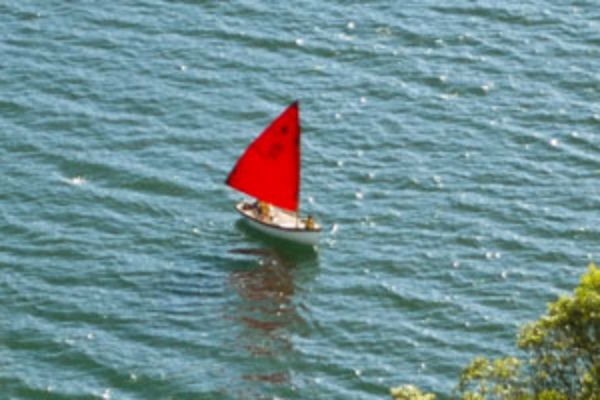

In [11]:
# Swap channel order
resized_cropped_region_2x = resized_cropped_region_2x[:,:,::-1]

# Save resized image to disk
cv2.imwrite("resized_cropped_region_2x.png", resized_cropped_region_2x)

# Display the cropped and resized image
Image(filename='resized_cropped_region_2x.png') 

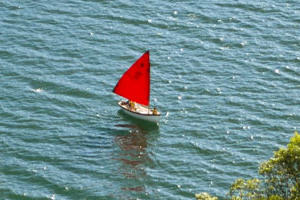

In [12]:
# Swap channel order
cropped_region = cropped_region[:,:,::-1]

# Save cropped 'region'
cv2.imwrite("cropped_region.png", cropped_region)

# Display the cropped and resized image
Image(filename='cropped_region.png')

# Invertendo Imagens

A função **`flip`** inverte a matriz de três maneiras diferentes (os índices de linha e coluna começam em 0):

### <font style="color:rgb(8,133,37)">Sintaxe da Função</font>
``` python
dst = cv.flip( src, flipCode )
```

`dst`: matriz de saída do mesmo tamanho e tipo que src.

A função possui **2 argumentos obrigatórios**:

1. `src`: imagem de entrada
2. `flipCode`: um parâmetro para especificar como inverter a matriz; 0 significa inverter em torno do eixo x e um valor positivo (por exemplo, 1) significa inverter em torno do eixo y. Um valor negativo (por exemplo, -1) significa inverter em torno de ambos os eixos.

### <font style="color:rgb(8,133,37)">Documentação do OpenCV</font>

**`flip:`** https://docs.opencv.org/4.5.0/d2/de8/group__core__array.html#gaca7be533e3dac7feb70fc60635adf441

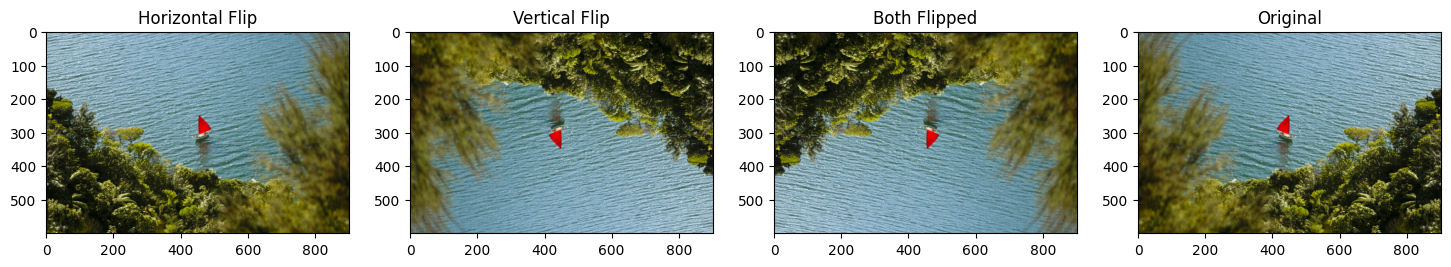

In [13]:
img_NZ_rgb_flipped_horz = cv2.flip(img_NZ_rgb, 1)
img_NZ_rgb_flipped_vert = cv2.flip(img_NZ_rgb, 0)
img_NZ_rgb_flipped_both = cv2.flip(img_NZ_rgb, -1)

# Show the images
plt.figure(figsize=[18,5])
plt.subplot(141);plt.imshow(img_NZ_rgb_flipped_horz);plt.title("Horizontal Flip");
plt.subplot(142);plt.imshow(img_NZ_rgb_flipped_vert);plt.title("Vertical Flip");
plt.subplot(143);plt.imshow(img_NZ_rgb_flipped_both);plt.title("Both Flipped");
plt.subplot(144);plt.imshow(img_NZ_rgb);plt.title("Original");